## Step 2 Data Cleaning

 Dropped empty column `Unnamed: column_number`
 Resampled to 1 Hz: `groupby('_Time').first()`
 Filtered in-flight data only: `iWOW == 0`

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("pandas :", pd.__version__)
print("numpy :", np.__version__)
print("matplotlib :", plt.matplotlib.__version__)

pandas : 3.0.3
numpy : 2.5.0
matplotlib : 3.11.0


In [16]:
df = pd.read_csv(r"C:\Users\TAD\Desktop\flight_analysis\flight_analysis\data_local\05.15.26.desynchro&etranglement.Koder\Parameters1.csv", sep=";")
df.head(1000)

,_Time,ALT(KNEI),IAS(KNEI),Roll(KNEI),Pitch(KNEI),Head(KNEI),Ngg_LH,Ngg_RH,NR,iWOW_LH,iWOW_RH,iStart_LH,iStart_RH,CPCL,Tg_LH,Tg_RH,Unnamed: 16
0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.785288,1.539171,0.91716,0.0,0.0,0.0,0.0,0.927536,65.384615,89.230769,NaN
1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.785288,1.539171,0.91716,0.0,0.0,0.0,0.0,0.927536,65.384615,89.743590,NaN
2,0.0,NaN,0.0,0.000000,0.000000,0.000000,0.785288,1.539171,0.91716,0.0,0.0,0.0,0.0,0.927536,NaN,NaN,NaN
3,0.0,NaN,0.0,0.000000,0.000000,0.000000,0.785288,1.539171,0.91716,0.0,0.0,0.0,0.0,0.927536,NaN,NaN,NaN
4,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.785288,1.539171,0.91716,0.0,0.0,0.0,0.0,0.927536,65.384615,89.230769,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,248.0,NaN,0.0,0.708618,3.823242,144.170837,0.785288,1.539171,0.91716,0.0,0.0,0.0,0.0,0.927536,NaN,NaN,NaN
996,249.0,51.5,0.0,0.714111,3.812256,144.173584,0.785288,1.539171,0.91716,0.0,0.0,0.0,0.0,0.927536,64.743590,89.743590,NaN
997,249.0,51.5,0.0,0.714111,3.823242,144.173584,0.785288,1.539171,0.91716,0.0,0.0,0.0,0.0,0.927536,64.743590,90.256410,NaN
998,249.0,NaN,0.0,0.703125,3.823242,144.176331,0.785288,1.539171,0.91716,0.0,0.0,0.0,0.0,0.927536,NaN,NaN,NaN


In [17]:
print(df.shape)
print(df.columns.tolist())

(24916, 17)
['_Time', 'ALT(KNEI)', 'IAS(KNEI)', 'Roll(KNEI)', 'Pitch(KNEI)', 'Head(KNEI)', 'Ngg_LH', 'Ngg_RH', 'NR', 'iWOW_LH', 'iWOW_RH', 'iStart_LH', 'iStart_RH', 'CPCL', 'Tg_LH', 'Tg_RH', 'Unnamed: 16']


In [18]:
nb_secondes = df.shape[0] / 4
nb_minutes = nb_secondes / 60
nb_heures = nb_minutes // 60
reste_minutes = nb_minutes % 60
print(f"Durée estimée : {nb_secondes:.0f} secondes soit {nb_minutes:.1f} minutes donc {nb_heures:.0f} h {reste_minutes:.0f} min")

Durée estimée : 6229 secondes soit 103.8 minutes donc 1 h 44 min


In [19]:
df.isnull().sum()

_Time              0
ALT(KNEI)      12458
IAS(KNEI)          0
Roll(KNEI)         0
Pitch(KNEI)        0
Head(KNEI)         0
Ngg_LH             0
Ngg_RH             0
NR                 0
iWOW_LH            0
iWOW_RH            0
iStart_LH          0
iStart_RH          0
CPCL               0
Tg_LH          12458
Tg_RH          12458
Unnamed: 16    24916
dtype: int64

In [20]:
df = df.drop(columns=['Unnamed: 16'])
print(df.shape)

(24916, 16)


In [30]:
df_1hz = df.groupby('_Time').first().reset_index()
temps_total = df_1hz.shape[0]
print(df_1hz.shape)

(6229, 16)


In [31]:
df_vol = df_1hz[df_1hz['iWOW_LH'] == 0]
temps_en_vol = df_vol.shape[0]
print(df_vol.shape)

(1784, 16)


In [32]:
sol = temps_total - temps_en_vol
print(f"Temps au sol : {sol} secondes soit {sol/60:.1f} minutes")

Temps au sol : 4445 secondes soit 74.1 minutes


In [37]:
df_vol.describe()

,_Time,ALT(KNEI),IAS(KNEI),Roll(KNEI),Pitch(KNEI),Head(KNEI),Ngg_LH,Ngg_RH,NR,iWOW_LH,iWOW_RH,iStart_LH,iStart_RH,CPCL,Tg_LH,Tg_RH
count,1784.000000,1784.000000,1784.0,1784.000000,1784.000000,1784.000000,1784.000000,1784.000000,1784.000000,1784.0,1784.000000,1784.000000,1784.000000,1784.000000,1784.000000,1784.000000
mean,2339.772422,-4.078756,0.0,-0.216875,2.962415,-10.159819,59.045689,55.974408,59.197710,0.0,0.020740,0.002803,0.002803,1.048389,459.811094,431.527690
std,2079.893339,13.120108,0.0,0.555672,1.236945,119.553860,37.857217,38.103586,39.305538,0.0,0.142552,0.052881,0.052881,0.529802,251.681431,237.121346
min,0.000000,-24.500000,0.0,-2.697144,0.000000,-175.457153,0.785288,1.539171,0.917160,0.0,0.000000,0.000000,0.000000,0.920290,60.256410,87.692308
25%,445.750000,-10.125000,0.0,-0.571289,2.477417,-126.875610,0.785288,1.539171,0.917160,0.0,0.000000,0.000000,0.000000,0.923913,146.794872,90.256410
50%,891.500000,-5.000000,0.0,-0.208740,3.246460,-83.789978,74.804805,73.808050,65.840164,0.0,0.000000,0.000000,0.000000,0.923913,609.281437,570.909091
75%,3852.250000,-3.500000,0.0,0.000000,3.834229,144.190750,87.271739,85.997807,93.552083,0.0,0.000000,0.000000,0.000000,0.927536,625.748503,602.409639
max,6230.000000,51.500000,0.0,0.994263,5.196533,179.041443,93.555094,93.910939,97.135417,0.0,1.000000,1.000000,1.000000,6.634538,780.124224,764.197531


In [38]:
print("IAS min:", df_vol['IAS(KNEI)'].min())
print("IAS max", df_vol['IAS(KNEI)'].max())
print("RAlt min:", df_vol['ALT(KNEI)'].min())
print("Heading max:", df_vol['Head(KNEI)'].max())

IAS min: 0.0
IAS max 0.0
RAlt min: -24.5
Heading max: 179.04144287


## Step 3 Exploratory Visualization

 Interactive multi-parameter chart (Ngg_LH/RH, Tg_LH/RH, Nmr, Roll, Pitch)
 X-axis in HH:MM:SS format, values rounded to 2 decimal places
 Hover: time, value, parameter name on one line

In [46]:
%matplotlib notebook

In [47]:
df_vol['time_fmt'] = pd.to_datetime('1970-01-01') + pd.to_timedelta(df_vol['_Time'], unit='s')

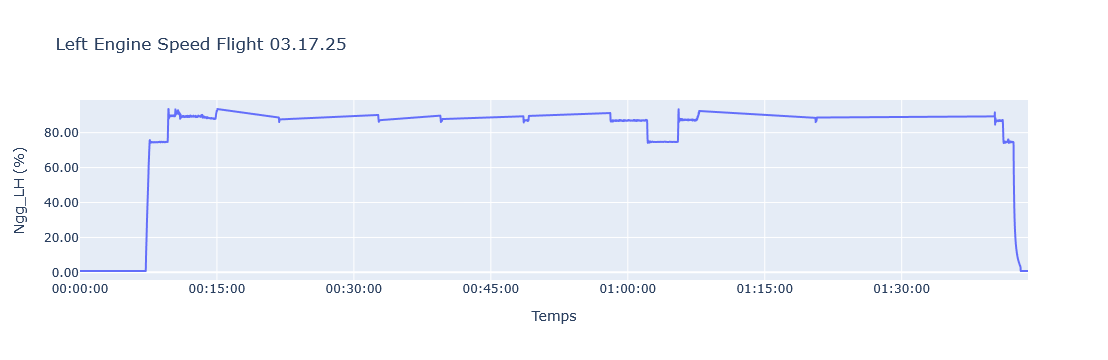

In [48]:
fig = px.line(df_vol, x='time_fmt', y='Ngg_LH',
              title='Left Engine Speed Flight 03.17.25',
              labels={'time_fmt': 'Temps', 'Ngg_LH': 'Ngg_LH (%)'})

fig.update_xaxes(tickformat="%H:%M:%S")
fig.update_yaxes(tickformat=".2f")
fig.show()

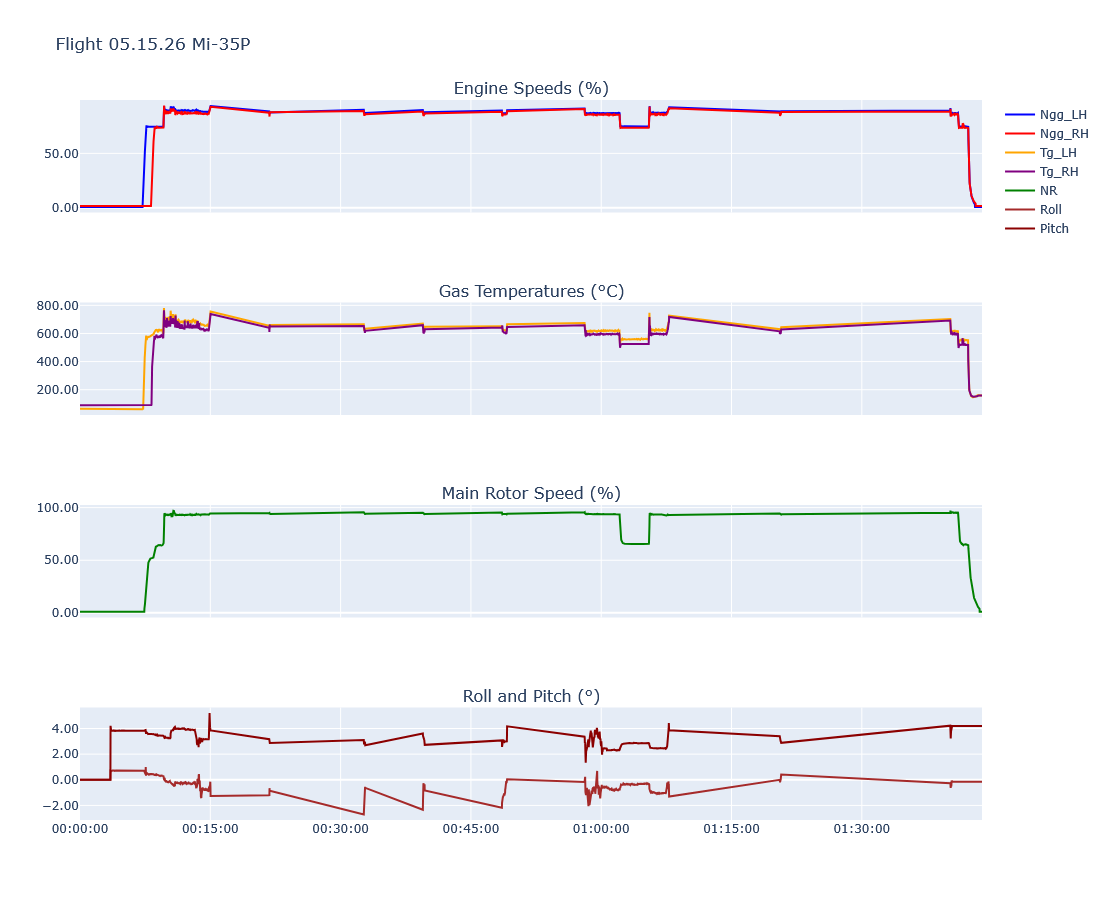

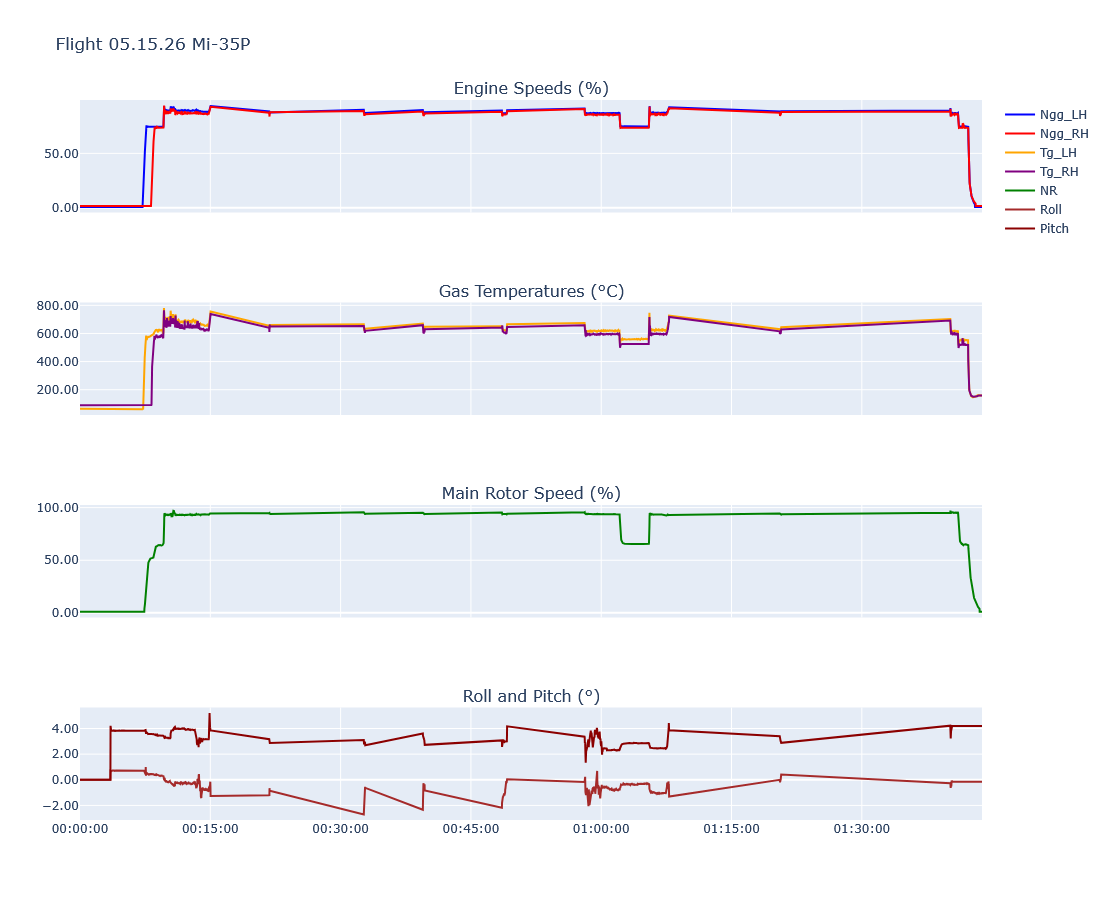

In [53]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=4, cols=1, shared_xaxes=True,
                    subplot_titles=('Engine Speeds (%)',
                        'Gas Temperatures (°C)',
                        'Main Rotor Speed (%)',
                        'Roll and Pitch (°)'))

fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Ngg_LH'], name='Ngg_LH', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Ngg_RH'], name='Ngg_RH', line=dict(color='red')), row=1, col=1)

fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Tg_LH'], name='Tg_LH', line=dict(color='orange')), row=2, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Tg_RH'], name='Tg_RH', line=dict(color='purple')), row=2, col=1)

fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['NR'], name='NR', line=dict(color='green')), row=3, col=1)

fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Roll(KNEI)'], name='Roll', line=dict(color='brown')), row=4, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Pitch(KNEI)'], name='Pitch', line=dict(color='darkred')), row=4, col=1)

fig.update_xaxes(tickformat="%H:%M:%S")
fig.update_yaxes(tickformat=".2f")
fig.update_layout(height=900, title_text="Flight 05.15.26 Mi-35P")
fig.show()
fig.update_traces(hovertemplate="%{x|%H:%M:%S}  %{y:.2f}  %{fullData.name}<extra></extra>")

## FLIGHT PASSPORT

## Manufacturer Limits Automatic Loading

 `charger_limitations(recorder_type)` reads the reference docx files
 BUR → `Limitations Technique Mi17V5 ENG.docx`
 Koder → `Limitations Technique Mi35P ENG.docx`
 Thresholds extracted automatically using regular expressions
 `LIMITS` replaces any hard-coded dictionary

In [ ]:
import subprocess
subprocess.run(['conda', 'install', '-y', 'python-docx'], capture_output=True)

In [ ]:
import os
from docx import Document
import re

def charger_limitations(recorder_type, dossier_ref=r"C:\Users\USER\Desktop\flight_analysis\data_local\references"):
    noms = {
        'BUR':   'Limitations Technique Mi17V5 ENG.docx',
        'Koder': 'Limitations Technique Mi35P ENG.docx'
    }
    chemin = os.path.join(dossier_ref, noms[recorder_type])
    print("Chemin :", chemin)

    doc = Document(chemin)
    parties = [p.text for p in doc.paragraphs]
    for table in doc.tables:
        for row in table.rows:
            for cell in row.cells:
                parties.append(cell.text)
    texte = ' '.join(parties)
    texte = texte.replace(',', '.')
    texte = re.sub(r'(?<!\d)(\d)\s(\d)(?!\d)', r'\1\2', texte)

    tg_m       = re.search(r'(\d{3})\s+\d{3}\s+(\d{3})\s+(?:\d{3}|-+)\s+Cruise', texte)
    tg_cruise  = int(tg_m.group(1)) if tg_m else None
    tg_takeoff = int(tg_m.group(2)) if tg_m else None

    nmr_max = int(re.search(r'Nmr max\s+(\d+)', texte).group(1))
    nmr_min = int(re.search(r'Nmr min\s+(\d+)', texte).group(1))

    ngg_max_m  = re.search(r'Emerg\s*[≤<]\s*(\d+\.?\d*)', texte)
    ngg_max    = float(ngg_max_m.group(1)) if ngg_max_m else 103.5
    ngg_cru_m  = re.search(r'Cruise\s+(\d+\.\d+)[±]', texte)
    ngg_cruise = float(ngg_cru_m.group(1)) if ngg_cru_m else 98.5

    roll_m    = re.search(r'Roll\s+Not more\s+[±\s]*(\d+)', texte)
    roll_max  = int(roll_m.group(1)) if roll_m else 30
    pitch_m   = re.search(r'Pitch\s+Not more\s+[±\s]*(\d+)', texte)
    pitch_max = int(pitch_m.group(1)) if pitch_m else 20

    ias_m   = re.search(r'V max / V min[.,]\s*km/h\s+(\d+)', texte)
    ias_max = int(ias_m.group(1)) if ias_m else 250

    u27_vals  = re.findall(r'Not less\s+(\d+\.?\d*)V', texte)
    u27_min   = float(u27_vals[1]) if len(u27_vals) >= 2 else 24.3
    u27_max_m = re.search(r'Not more\s+(\d+)V', texte)
    u27_max   = int(u27_max_m.group(1)) if u27_max_m else 31

    limites = {
        'Tg_LH':  {'cruise_max': tg_cruise, 'takeoff_max': tg_takeoff},
        'Tg_RH':  {'cruise_max': tg_cruise, 'takeoff_max': tg_takeoff},
        'Nmr':    {'min': nmr_min, 'normal_min': 91, 'normal_max': 97, 'max': nmr_max},
        'Ngg_LH': {'cruise': ngg_cruise, 'max': ngg_max},
        'Ngg_RH': {'cruise': ngg_cruise, 'max': ngg_max},
        'Roll':   {'max': roll_max},
        'Pitch':  {'max': pitch_max},
        'IAS':    {'max': ias_max},
        'U27':    {'min': u27_min, 'max': u27_max}
    }

    for p, v in limites.items():
        print(f"  {p}: {v}")
    return limites

In [ ]:
import os

DOSSIER_REF = r"C:\Users\USER\Desktop\flight_analysis\data_local\references"

In [ ]:
LIMITS = {
    'BUR':   charger_limitations('BUR'),
    'Koder': charger_limitations('Koder')
}

In [77]:
def charger_vol(chemin, recorder_type):
    df_flight = pd.read_csv(chemin, sep=';')
    df_flight = df_flight.drop(columns=['Unnamed: 26'], errors='ignore')
    df_flight = df_flight.groupby('_Time').first().reset_index()

    col_wow = 'iWOW' if recorder_type == 'BUR' else 'iWOW_LH'
    df_flight = df_flight[df_flight[col_wow] == 0]

    df_flight['time_fmt'] = pd.to_datetime('1970-01-01') + pd.to_timedelta(df_flight['_Time'], unit='s')
    return df_flight

In [78]:
df_flight = charger_vol(
    r"C:\Users\TAD\Desktop\flight_analysis\flight_analysis\data_local\06.05.26.Tirops.Koder\Parameters1.csv",
    'Koder'
)
print(df_flight.shape)

(1055, 27)


In [79]:
print(df_flight.columns.tolist())

['_Time', 'ALT(KNEI)', 'IAS(KNEI)', 'Roll(KNEI)', 'Pitch(KNEI)', 'Head(KNEI)', 'Ngg_LH', 'Ngg_RH', 'NR', 'iWOW_LH', 'iWOW_RH', 'iStart_LH', 'iStart_RH', 'iAPU', 'iPoil_LH_min', 'iPoil_RH_min', 'iPoil_MGB_min', 'iChips_LH', 'iChips_RH', 'iChips_MGB', 'iChips_IGB', 'iChips_TGB', 'iChips_GB', 'iFire_APU', 'iFire_MGB', 'Time(Koder)', 'time_fmt']


In [ ]:
parametres = ['Ngg_LH', 'Ngg_RH', 'Nmr', 'NR', 'Roll(KNEI)', 'Pitch(KNEI)', 'IAS(KNEI)', 'ALT(KNEI)', 'Tg_LH', 'Tg_RH', 'Roll', 'Pitch']

X = df_vol[parametres].dropna()
print(f"Data available : {len(X)} on {len(df_vol)}")

In [82]:
def detecter_violations(df_flight, recorder_type):
    limites = LIMITS[recorder_type]
    violations = []

    for parametre, seuils in limites.items():
        if parametre not in df_flight.columns:
            continue

        if 'max' in seuils:
            depassements = df_flight[abs(df_flight[parametre]) > seuils['max']]
            for _, ligne in depassements.iterrows():
                violations.append({
                    'time': ligne['time_fmt'],
                    'parametre': parametre,
                    'valeur': round(ligne[parametre], 2),
                    'seuil': seuils['max'],
                    'type': 'MAX'
                })

        if 'min' in seuils:
            depassements = df_flight[df_flight[parametre] < seuils['min']]
            for _, ligne in depassements.iterrows():
                violations.append({
                    'time': ligne['time_fmt'],
                    'parametre': parametre,
                    'valeur': round(ligne[parametre], 2),
                    'seuil': seuils['min'],
                    'type': 'MIN'
                })

    return pd.DataFrame(violations)

In [83]:
violations_bur = detecter_violations(df_flight, 'BUR')
print(f"{len(violations_bur)} violations détectées")
violations_bur.head(20)

violations_koder = detecter_violations(df_flight, 'Koder')
print(f"{len(violations_koder)} violations détectées")
violations_koder.head(20)

0 violations détectées
0 violations détectées


""


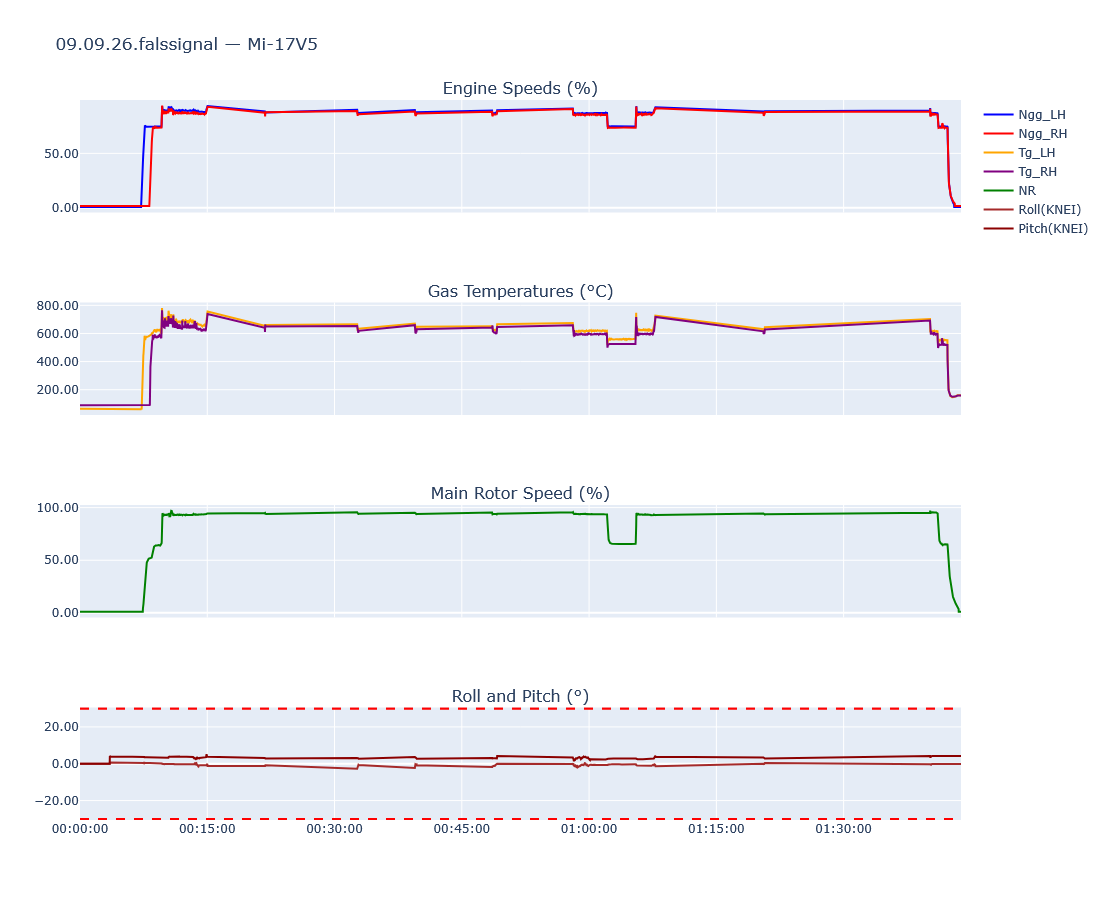

In [87]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=4, cols=1, shared_xaxes=True,
                    subplot_titles=('Engine Speeds (%)',
                        'Gas Temperatures (°C)',
                        'Main Rotor Speed (%)',
                        'Roll and Pitch (°)'))

fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Ngg_LH'], name='Ngg_LH', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Ngg_RH'], name='Ngg_RH', line=dict(color='red')), row=1, col=1)

fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Tg_LH'], name='Tg_LH', line=dict(color='orange')), row=2, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Tg_RH'], name='Tg_RH', line=dict(color='purple')), row=2, col=1)

fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['NR'], name='NR', line=dict(color='green')), row=3, col=1)

fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Roll(KNEI)'], name='Roll(KNEI)', line=dict(color='brown')), row=4, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Pitch(KNEI)'], name='Pitch(KNEI)', line=dict(color='darkred')), row=4, col=1)

# Lignes limites Roll
fig.add_hline(y=30, line_color='red', line_dash='dash', row=4, col=1)
fig.add_hline(y=-30, line_color='red', line_dash='dash', row=4, col=1)

fig.update_xaxes(tickformat="%H:%M:%S")
fig.update_yaxes(tickformat=".2f")
fig.update_layout(height=900, title_text="09.09.26.falssignal — Mi-17V5")
fig.add_hline(y=30, line_color='red', line_dash='dash', row=4, col=1)
fig.add_hline(y=-30, line_color='red', line_dash='dash', row=4, col=1)
fig.update_traces(hovertemplate="%{x|%H:%M:%S}  %{y:.2f}  %{fullData.name}<extra></extra>")
fig.show()

## Step 4 Anomaly Detection Level 1: Manufacturer Thresholds

 `LIMITS` dictionary encoding official Mi-17V5 and Mi-35P limitations
 `detect_violations(df, recorder_type)`

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Mise à l'échelle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entraînement
modele = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
modele.fit(X_scaled)

print("Model trained.")

In [ ]:
# Prédictions : -1 = anomalie, 1 = normal
df_vol = df_vol.copy()
df_vol.loc[X.index, 'anomalie'] = modele.predict(X_scaled)
df_vol.loc[X.index, 'score']    = modele.score_samples(X_scaled)

# Compter les anomalies
n_anomalies = (df_vol['anomalie'] == -1).sum()
print(f"Anomalies détectées : {n_anomalies} secondes ({n_anomalies/len(df_vol)*100:.1f}%)")

In [ ]:
fig = make_subplots(rows=5, cols=1, shared_xaxes=True,
                    subplot_titles=('Engine Speeds (%)',
                        'Gas Temperatures (°C)',
                        'Main Rotor Speed (%)',
                        'Roll and Pitch (°)'))

fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Ngg_LH'], name='Ngg_LH', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Ngg_RH'], name='Ngg_RH', line=dict(color='red')), row=1, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Tg_LH'], name='Tg_LH', line=dict(color='orange')), row=2, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Tg_RH'], name='Tg_RH', line=dict(color='purple')), row=2, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Nmr'], name='Nmr', line=dict(color='green')), row=3, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Roll'], name='Roll', line=dict(color='brown')), row=4, col=1)
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['Pitch'], name='Pitch', line=dict(color='darkred')), row=4, col=1)

# Score d'anomalie
fig.add_trace(go.Scatter(x=df_vol['time_fmt'], y=df_vol['score'],
                         name='Score', line=dict(color='gray')), row=5, col=1)

# Points rouges sur les anomalies détectées
anomalies = df_vol[df_vol['anomalie'] == -1]
fig.add_trace(go.Scatter(x=anomalies['time_fmt'], y=anomalies['score'],
                         mode='markers', marker=dict(color='red', size=6),
                         name='Anomalie IF'), row=5, col=1)

fig.update_xaxes(tickformat="%H:%M:%S")
fig.update_yaxes(tickformat=".2f")
fig.update_layout(height=1100, title_text="Vol 03.17.25 — Isolation Forest")
fig.update_traces(hovertemplate="%{x|%H:%M:%S}  %{y:.2f}  %{fullData.name}<extra></extra>")
fig.show()

In [ ]:
print(" Périodes NORMALES ")
print(df_vol[df_vol['anomalie'] == 1][parametres].mean().round(2))

print("\n Périodes ANOMALIES ")
print(df_vol[df_vol['anomalie'] == -1][parametres].mean().round(2))

## Step 4 Anomaly Detection Level 2: Isolation Forest

 StandardScaler applied to normalize 7 parameters to the same scale
 IsolationForest: 100 trees, contamination=1%
 136 seconds flagged (1.0% of flight)

## Step 5 Critical Evaluation

### Level 1 Manufacturer Thresholds
   Reliable for clear limit violations
   Blind to subtle anomalies below thresholds
   Cannot detect gradual degradation trends

### Level 2 Isolation Forest
   Detects statistically unusual behavior without prior knowledge
   Flags rare but normal flight phases (false positives)
   Sensitive to the contamination parameter
   Blind to slow progressive degradation

### Common Limitation
Both methods are blind to progressive degradation.
Such cases require temporal trend analysis autoencoder or sliding window regression.

### What Would Strengthen the Pipeline
1. Label known flights (normal/abnormal) to switch to supervised learning
2. Add trend detection (slope over a sliding window)
3. Cross both levels: keep only anomalies flagged by both methods

In [ ]:
gitignore = """# Données réelles jamais publiées
data_local/

# Fichiers système
.DS_Store
__pycache__/
*.pyc
.ipynb_checkpoints/
"""

with open(r"C:\Users\USER\Desktop\flight_analysis\.gitignore", "w") as f:
    f.write(gitignore)

print(".gitignore créé.")

In [ ]:
requirements = """pandas
numpy
matplotlib
plotly
scikit-learn
python-docx
"""

with open(r"C:\Users\USER\Desktop\flight_analysis\requirements.txt", "w") as f:
    f.write(requirements)
print("requirements.txt created.")

In [98]:
readme = """# Flight Data Analysis & Anomaly Detection

Pipeline for analyzing helicopter flight recorder data (Mi-17V5 and Mi-35P) 
exported from SCAT software.

## Overview
- **Aircraft**: Mi-17V5 (BUR recorder) and Mi-35P (Koder-35M recorder)
- **Data**: 8 flights, CSV format, 1Hz resampled
- **Methods**: Manufacturer threshold detection + Isolation Forest

## Pipeline
1. Data loading and resampling to 1Hz
2. In-flight filtering (Weight-on-Wheels sensor)
3. Interactive multi-parameter visualization (Plotly)
4. Anomaly detection: Level 1: manufacturer limits (auto-loaded from docx)
5. Anomaly detection: Level 2: Isolation Forest (scikit-learn)
6. Critical evaluation of results

## Structure
flight_analysis/
    notebooks/ # Jupyter notebooks
    data_local/ # Real flight data (not shared)
    data_public/ # Anonymized samples
    README.md
    Requierment.txt

## Requirements
pip install -r requirements.txt
"""
with open(r"C:\Users\TAD\Desktop\flight_analysis\flight_analysis\README.md", "w", encoding='utf-8') as f:
    f.write(readme)
print("README.md created.")

README.md created.


In [ ]:
def analyser_tous_les_vols(dossier_data):
    resultats = []

    for nom_dossier in os.listdir(dossier_data):
        chemin_dossier = os.path.join(dossier_data, nom_dossier)
        if not os.path.isdir(chemin_dossier):
            continue

        # Détecter le type d'enregistreur depuis le nom du dossier
        if 'BUR' in nom_dossier.upper():
            recorder = 'BUR'
        elif 'KODER' in nom_dossier.upper():
            recorder = 'Koder'
        else:
            continue

        # Trouver le fichier CSV dans le dossier
        csv_files = [f for f in os.listdir(chemin_dossier) if f.endswith('.csv')]
        if not csv_files:
            continue

        chemin_csv = os.path.join(chemin_dossier, csv_files[0])

        try:
            df = charger_vol(chemin_csv, recorder)
            violations = detecter_violations(df, recorder)
            resultats.append({
                'vol': nom_dossier,
                'recorder': recorder,
                'duree_s': len(df),
                'violations': len(violations),
                'detail': violations
            })
            print(f"✓ {nom_dossier} — {len(violations)} violation(s)")
        except Exception as e:
            print(f"✗ {nom_dossier} — erreur: {e}")

    return resultats

In [ ]:
DOSSIER_DATA = r"C:\Users\USER\Downloads\Telegram Desktop\AnnalyseData\AnnalyseData"

In [ ]:
tous_les_vols = analyser_tous_les_vols(DOSSIER_DATA)

In [ ]:
from docx import Document
from docx.shared import RGBColor

def generate_report(chemin_csv, recorder_type, flight_name,
                    dossier_sortie=r"C:\Users\USER\Desktop\flight_analysis\data_public"):
    df     = charger_vol(chemin_csv, recorder_type)
    limits = charger_limitations(recorder_type, dossier_ref=DOSSIER_REF)
    viols  = detecter_violations(df, recorder_type)

    def rng(col):
        s = df[col].dropna()
        return f"{s.min():.1f} ÷ {s.max():.1f}" if col in df.columns else 'N/A'
    def mx(col):
        return f"{df[col].dropna().max():.1f}" if col in df.columns else 'N/A'
    def absmx(col):
        return f"±{df[col].dropna().abs().max():.1f}" if col in df.columns else 'N/A'
    def viol_text(param):
        if len(viols) == 0 or param not in viols['parametre'].values:
            return 'None', False
        r = viols[viols['parametre'] == param].iloc[0]
        return f"{r['type']}: {r['valeur']:.2f} (limit {r['seuil']})", True

    doc = Document()
    doc.add_heading('REPORT From FDR Data', 0)

    info = doc.add_table(rows=4, cols=2)
    info.style = 'Table Grid'
    aircraft = 'Mi-17V5' if recorder_type == 'BUR' else 'Mi-35P'
    for i, (k, v) in enumerate([('Flight ID:', flight_name),
                                  ('Aircraft:', aircraft),
                                  ('FDR type:', recorder_type),
                                  ('Recorder:', 'BUR' if recorder_type == 'BUR' else 'KODER-35-1')]):
        info.cell(i, 0).text = k
        info.cell(i, 1).text = v

    doc.add_paragraph()
    tbl = doc.add_table(rows=1, cols=5)
    tbl.style = 'Table Grid'
    for i, c in enumerate(['Monitored parameters', 'Normal value',
                            'Actual value', 'Detected problems', 'Remarks']):
        tbl.rows[0].cells[i].paragraphs[0].add_run(c).bold = True

    def section_row(title):
        cells = tbl.add_row().cells
        cells[0].paragraphs[0].add_run(title).bold = True

    def param_row(name, normal, actual, key=None):
        cells = tbl.add_row().cells
        cells[0].text = name
        cells[1].text = normal
        cells[2].text = actual
        if key:
            txt, is_v = viol_text(key)
            cells[3].text = txt
            if is_v:
                cells[3].paragraphs[0].runs[0].font.color.rgb = RGBColor(0xFF, 0x00, 0x00)
        else:
            cells[3].text = 'None'
        cells[4].text = ''

    section_row('1. Engine parameters')
    param_row('Main rotor RPM (Nmr)',      '91 ÷ 97 %',                  rng('Nmr')  + ' %', 'Nmr')
    param_row('LH engine RPM (Ngg_LH)',    f"≤ {limits['Ngg_LH']['max']} %", mx('Ngg_LH') + ' %', 'Ngg_LH')
    param_row('RH engine RPM (Ngg_RH)',    f"≤ {limits['Ngg_RH']['max']} %", mx('Ngg_RH') + ' %', 'Ngg_RH')
    param_row('LH gas temperature (Tg_LH)',f"≤ {limits['Tg_LH']['cruise_max']} °C",  mx('Tg_LH')  + ' °C', 'Tg_LH')
    param_row('RH gas temperature (Tg_RH)',f"≤ {limits['Tg_RH']['cruise_max']} °C",  mx('Tg_RH')  + ' °C', 'Tg_RH')

    if 'Ngg_LH' in df.columns and 'Ngg_RH' in df.columns:
        diff = (df['Ngg_LH'] - df['Ngg_RH']).abs().max()
        c = tbl.add_row().cells
        c[0].text = 'Engine RPM difference LH/RH'
        c[1].text = '≤ 2 %'
        c[2].text = f'{diff:.2f} %'
        c[3].text = 'None' if diff <= 2.0 else f'EXCEEDED: {diff:.2f} %'
        if diff > 2.0:
            c[3].paragraphs[0].runs[0].font.color.rgb = RGBColor(0xFF, 0x00, 0x00)
        c[4].text = ''

    section_row('2. Flight dynamics')
    param_row('Roll maximum',              f"± {limits['Roll']['max']} °",  absmx('Roll')  + ' °', 'Roll')
    param_row('Pitch maximum',             f"± {limits['Pitch']['max']} °", absmx('Pitch') + ' °', 'Pitch')
    param_row('Indicated speed max (IAS)', f"≤ {limits['IAS']['max']} km/h", mx('IAS')   + ' km/h', 'IAS')

    section_row('3. Electrical system')
    param_row('DC bus voltage (U27)',
              f"{limits['U27']['min']} ÷ {limits['U27']['max']} V",
              rng('U27') + ' V', 'U27')

    section_row('4. Summary')
    s = len(df)
    c = tbl.add_row().cells
    c[0].text = 'Total violations'; c[1].text = '0'
    c[2].text = str(len(viols)); c[3].text = 'See above' if len(viols) > 0 else 'None'; c[4].text = ''
    c2 = tbl.add_row().cells
    c2[0].text = 'Flight duration'; c2[1].text = '-'
    c2[2].text = f'{s} s ({s//60} min {s%60} s)'; c2[3].text = '-'; c2[4].text = ''

    doc.add_paragraph()
    doc.add_paragraph('Other detected problems: _________________________________________________')
    doc.add_paragraph('Objective control specialist: _____________________')
    doc.add_paragraph('PIC: _____________________')

    os.makedirs(dossier_sortie, exist_ok=True)
    path = os.path.join(dossier_sortie, f'report_{flight_name}.docx')
    doc.save(path)
    print(f'Report saved: {path}')
    return path

In [ ]:
generate_report(
    chemin_csv=r"C:\Users\USER\Downloads\Telegram Desktop\AnnalyseData\AnnalyseData\09.09.26.falssignal.BUR\Parameters.csv",
    recorder_type='BUR',
    flight_name='09.09.26.falssignal'
)